# Definição - Fuzzy

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

freio = ctrl.Consequent(np.arange(0, 100, 1), 'Freio')
aprox = ctrl.Antecedent(np.arange(0, 14, 1), 'Aproximação')
dist = ctrl.Antecedent(np.arange(0, 60, 1), 'Distância em metros')

freio['Pisadinha'] = fuzz.trapmf(freio.universe, [0, 0, 10, 25])
freio['Intermediária'] = fuzz.trapmf(freio.universe, [20, 30,60, 85])
freio['Pisar até o Fim'] = fuzz.trapmf(freio.universe, [80, 90, 100, 100])

aprox['Devagar'] = fuzz.trapmf(aprox.universe, [0, 0, 3, 5])
aprox['Rápido'] = fuzz.trapmf(aprox.universe, [4, 6, 8, 10])
aprox['Muito rápido'] = fuzz.trapmf(aprox.universe, [9, 12, 14, 14])

dist['Perto'] = fuzz.trapmf(dist.universe, [0, 0, 8, 15])
dist['Longe'] = fuzz.trapmf(dist.universe, [10, 50, 60, 60])

## Gráficos

/home/thiago_lins/dev/senac/IA/IA-EP3/.venv/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


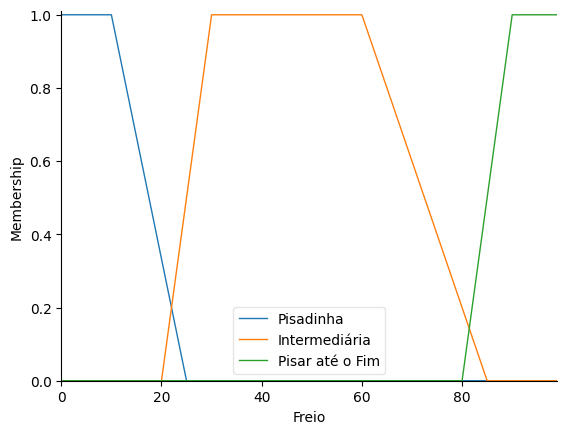

In [2]:
freio.view()

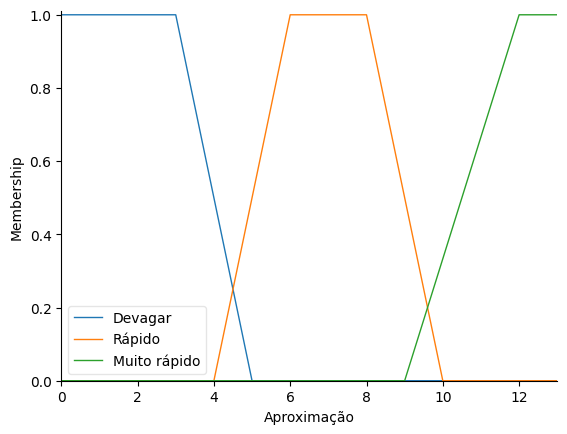

In [3]:
aprox.view()

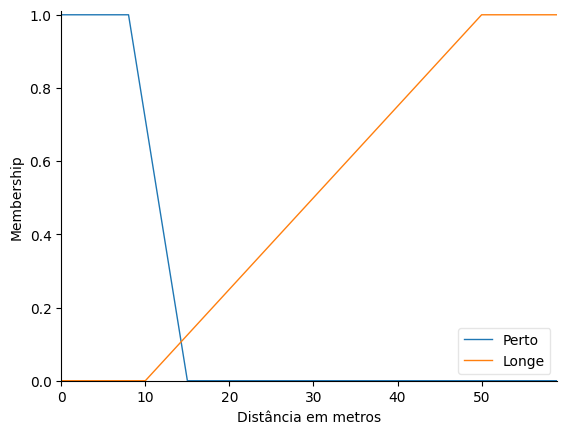

In [4]:
dist.view()

# Regras

In [5]:
# Se aprox X e dist Y, então freio Z
rule1 = ctrl.Rule(aprox['Rápido'] & dist['Longe'], freio['Pisar até o Fim'])
rule2 = ctrl.Rule(aprox['Muito rápido'] & dist['Perto'], freio['Pisar até o Fim'])
rule3 = ctrl.Rule(aprox['Rápido'] & dist['Longe'], freio['Pisadinha'])
rule4 = ctrl.Rule(aprox['Muito rápido'] | dist['Longe'], freio['Intermediária'])
rule5 = ctrl.Rule(aprox['Devagar'] & dist['Perto'], freio['Pisadinha'])

# Simulação

In [6]:
freio_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
freio_simulador = ctrl.ControlSystemSimulation(freio_ctrl)

freio_simulador.input['Aproximação'] = 3
freio_simulador.input['Distância em metros'] = 50

freio_simulador.compute()
print(freio_simulador.output['Freio'])

49.21052631578947


## Gráficos

aprox.view(sim=freio_simulador)

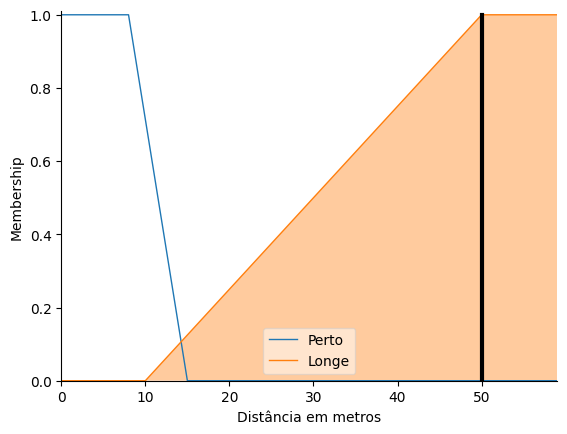

In [7]:
dist.view(sim=freio_simulador)